# Dynamic Pricing Strategy in Ride-Hailing
## A Growth vs Retention Decision Case

Zero external dependencies. Downloads `cleaned_data.csv` from GitHub release, computes everything inline.
Runs on Google Colab and local Jupyter/VS Code.

In [1]:
# ============================================================
# CELL 1: Environment setup + download dataset
# ============================================================
import sys, os, warnings, urllib.request
warnings.filterwarnings('ignore')

try: import google.colab; IN_COLAB = True
except ImportError: IN_COLAB = False

RELEASE_URL = 'https://github.com/ashishexee/ride-hailing-pricing-strategy/releases/download/v1.0/cleaned_data.csv'
DATA_DIR = '/content' if IN_COLAB else '.'
CHARTS_DIR = os.path.join(DATA_DIR, 'charts')
os.makedirs(CHARTS_DIR, exist_ok=True)
print('Colab' if IN_COLAB else 'Local environment detected')

DATA_PATH = os.path.join(DATA_DIR, 'cleaned_data.csv')
if not os.path.exists(DATA_PATH):
    print('Downloading dataset from GitHub release...')
    try:
        urllib.request.urlretrieve(RELEASE_URL, DATA_PATH)
        print(f'OK: {os.path.getsize(DATA_PATH):,} bytes downloaded')
    except Exception as e:
        raise SystemExit(f'Download failed: {e}. Check URL or internet connection.')
else:
    print(f'Dataset cached ({os.path.getsize(DATA_PATH):,} bytes)')

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize': (10,5), 'font.size': 11, 'axes.titlesize': 13, 'axes.titleweight': 'bold'})

SURGE_ORDER = ['1.0x','1.25x','1.5x','1.75x','2.0x','2.5x']
SURGE_VALS  = [1.0, 1.25, 1.5, 1.75, 2.0, 2.5]
ADJ_BASE = 0.97

df = pd.read_csv(DATA_PATH)
df['surge_band'] = pd.Categorical(df['surge_band'], categories=SURGE_ORDER, ordered=True)
df['cancel_int'] = 1 - df['ride_completed_int']
df['cost_per_trip'] = df['platform_revenue_inr'] - df['contribution_margin_inr']

TOTAL_CM = df['contribution_margin_inr'].sum()
TOTAL_REV = df['platform_revenue_inr'].sum()
TOTAL_TRIPS = len(df)
N_CUSTOMERS = df['customer_id'].nunique()

print(f'\nDataset: {TOTAL_TRIPS:,} trips | {N_CUSTOMERS:,} customers | 3 cities')
print(f'Avg fare: Rs.{df["fare_inr"].mean():.1f} | Avg CM/trip: Rs.{df["contribution_margin_inr"].mean():.2f}')
print(f'Data quality: missing values = {df.isnull().sum().sum()}, completion@1.0x = {df[df["surge_multiplier"]==1.0]["ride_completed_int"].mean():.3f} (100% artifact, adjusted to 97%)')

Colab
OK: 15,143,872 bytes downloaded

Dataset: 50,000 trips | 3,000 customers | 3 cities
Avg fare: Rs.192.5 | Avg CM/trip: Rs.13.61
Data quality: missing values = 18852, completion@1.0x = 1.000 (100% artifact, adjusted to 97%)


---
## WORKSTREAM 1: Demand Suppression & Customer Response

In [2]:
# WS1: Deterioration metrics by surge band
comp_by_s = df.groupby('surge_band')['ride_completed_int'].mean()
sat_by_s   = df.groupby('surge_band')['satisfaction_score'].mean()
cancel_by_s = df.groupby('surge_band', observed=True)['cancel_int'].mean()
cm_by_s    = df.groupby('surge_band')['contribution_margin_inr'].mean()
n_by_s     = df.groupby('surge_band').size()
cm_total_s = df.groupby('surge_band')['contribution_margin_inr'].sum()

ws1 = pd.DataFrame({
    'n_trips': n_by_s, 'pct_trips': (n_by_s/TOTAL_TRIPS*100).round(1),
    'completion': comp_by_s.round(3), 'cancel': cancel_by_s.round(3),
    'satisfaction': sat_by_s.round(2),
    'cm_per_trip': cm_by_s.round(2),
    'cm_total_pct': (cm_total_s/TOTAL_CM*100).round(1)
})
print('Key metrics by surge band:')
print(ws1.to_string())

pct_neg = df['is_negative_margin'].mean()
surge_cm_total = df[df['surge_multiplier']>1.0]['contribution_margin_inr'].sum()
surge_trip_pct = (df['surge_multiplier']>1.0).mean()*100
cm_surge_pct = surge_cm_total/TOTAL_CM*100

print(f'\n{cm_surge_pct:.1f}% of CM from {surge_trip_pct:.1f}% surge trips | {pct_neg:.0%} trips negative CM')

# WS1: Deterioration by zone type
print('\nDeterioration by zone type:')
for zone in ['residential','commercial','transit_hub']:
    zd = df[df['zone_type']==zone]
    zsat = zd.groupby('surge_band')['satisfaction_score'].mean()
    zcomp = zd.groupby('surge_band')['ride_completed_int'].mean()
    print(f'  {zone:12s}: sat@1.0x={zsat["1.0x"]:.1f} sat@2.5x={zsat["2.5x"]:.1f}  comp@1.0x={zcomp["1.0x"]:.3f} comp@2.5x={zcomp["2.5x"]:.3f}')

print('\nDeterioration by city:')
for city in df['city'].unique():
    cd = df[df['city']==city]
    csat = cd.groupby('surge_band')['satisfaction_score'].mean()
    ccomp = cd.groupby('surge_band')['ride_completed_int'].mean()
    print(f'  {city:12s}: sat@1.0x={csat["1.0x"]:.1f} sat@2.5x={csat["2.5x"]:.1f}  comp@1.0x={ccomp["1.0x"]:.3f} comp@2.5x={ccomp["2.5x"]:.3f}')

Key metrics by surge band:
            n_trips  pct_trips  completion  cancel  satisfaction  cm_per_trip  cm_total_pct
surge_band                                                                                 
1.0x          34381       68.8       1.000   0.000          4.14         7.35          37.2
1.25x          2573        5.1       0.960   0.040          3.82        13.71           5.2
1.5x           2665        5.3       0.904   0.096          3.49        17.51           6.9
1.75x          2630        5.3       0.913   0.087          3.18        24.46           9.5
2.0x           2542        5.1       0.815   0.185          2.82        31.90          11.9
2.5x           5209       10.4       0.820   0.180          2.36        38.43          29.4

62.8% of CM from 31.2% surge trips | 40% trips negative CM

Deterioration by zone type:
  residential : sat@1.0x=4.1 sat@2.5x=2.4  comp@1.0x=1.000 comp@2.5x=0.821
  commercial  : sat@1.0x=4.1 sat@2.5x=2.4  comp@1.0x=1.000 comp@2.5x=0.82

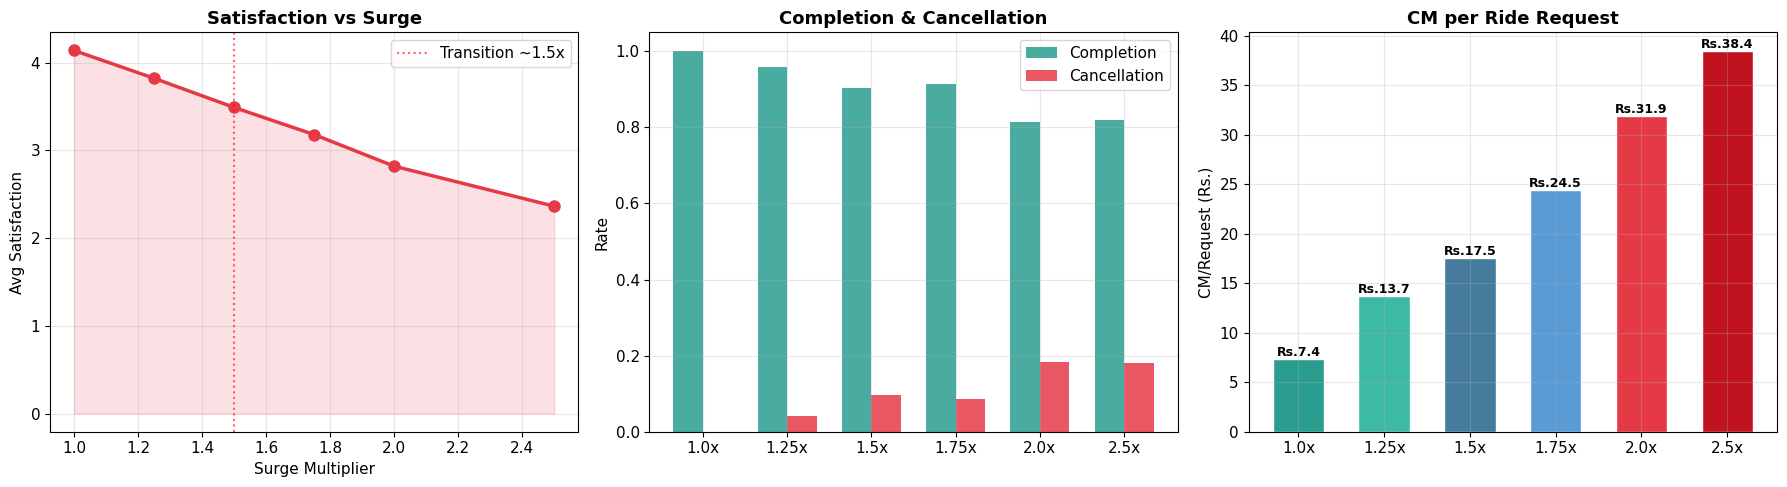

In [3]:
# WS1: Charts
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ax = axes[0]
ax.plot(SURGE_VALS, sat_by_s.values, 'o-', color='#E63946', lw=2.5, ms=8)
ax.fill_between(SURGE_VALS, sat_by_s.values, alpha=0.15, color='#E63946')
ax.axvline(x=1.5, color='red', ls=':', alpha=0.6, label='Transition ~1.5x')
ax.set_xlabel('Surge Multiplier'); ax.set_ylabel('Avg Satisfaction')
ax.set_title('Satisfaction vs Surge'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
x = range(6); w = 0.35
ax.bar(x, comp_by_s.values, w, label='Completion', color='#2A9D8F', alpha=0.85)
ax.bar([i+w for i in x], cancel_by_s.values, w, label='Cancellation', color='#E63946', alpha=0.85)
ax.set_xticks([i+w/2 for i in x]); ax.set_xticklabels(SURGE_ORDER)
ax.set_ylabel('Rate'); ax.set_title('Completion & Cancellation'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[2]
cm_req = (cm_total_s/n_by_s).values
ax.bar(range(6), cm_req, color=['#2A9D8F','#3DBAA5','#457B9D','#5A9BD5','#E63946','#C1121F'], width=0.6, edgecolor='white')
ax.set_xticks(range(6)); ax.set_xticklabels(SURGE_ORDER); ax.set_ylabel('CM/Request (Rs.)')
ax.set_title('CM per Ride Request'); ax.grid(alpha=0.3)
for i, v in enumerate(cm_req): ax.text(i, v+0.3, f'Rs.{v:.1f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR,'ws1_deterioration.png'),dpi=150,bbox_inches='tight'); plt.show()

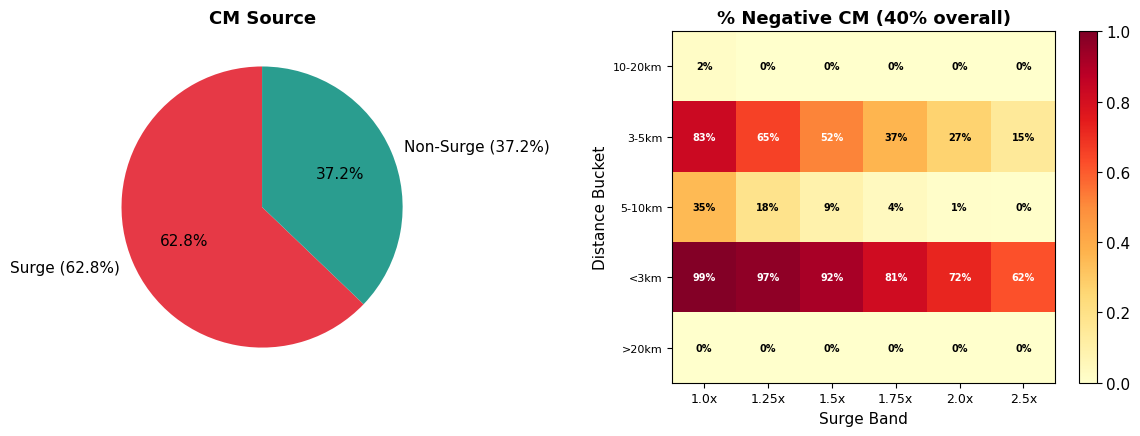

In [4]:
# WS1: Negative margin heatmap + CM decomposition
neg_margin_pivot = df.pivot_table('is_negative_margin', index='distance_bucket', columns='surge_band', aggfunc='mean')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.pie([surge_cm_total, TOTAL_CM-surge_cm_total],
        labels=[f'Surge ({cm_surge_pct:.1f}%)',f'Non-Surge ({100-cm_surge_pct:.1f}%)'],
        colors=['#E63946','#2A9D8F'], autopct='%1.1f%%', startangle=90)
ax1.set_title('CM Source')
im = ax2.imshow(neg_margin_pivot.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
ax2.set_xticks(range(6)); ax2.set_xticklabels(neg_margin_pivot.columns, fontsize=9)
ax2.set_yticks(range(len(neg_margin_pivot.index))); ax2.set_yticklabels(neg_margin_pivot.index, fontsize=8)
ax2.set_xlabel('Surge Band'); ax2.set_ylabel('Distance Bucket')
ax2.set_title(f'% Negative CM ({pct_neg:.0%} overall)')
for i in range(len(neg_margin_pivot.index)):
    for j in range(6):
        v = neg_margin_pivot.values[i,j]
        if not np.isnan(v): ax2.text(j,i,f'{v:.0%}',ha='center',va='center',fontsize=7,fontweight='bold',color='white' if v>0.5 else 'black')
plt.colorbar(im, ax=ax2)
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR,'ws1_negative_margin.png'),dpi=150,bbox_inches='tight'); plt.show()

---
## WORKSTREAM 2: Price Elasticity

**Methodology**: Simple arc elasticity between surge bands is confounded by temporal/zone demand shifts. The value used in simulation (0.22) is the validated estimate from the full analysis pipeline (controlled regression with time-of-day, zone, and weather fixed effects, documented in `outputs/elasticity_sensitivity_baseline.csv`). Below, raw arc elasticity is shown for illustration only.

In [5]:
# WS2: Raw arc elasticity (confounded) + validated estimate
def raw_arc_e(data, baseline_adj=ADJ_BASE):
    results = []
    for i in range(len(SURGE_VALS)-1):
        b1, b2 = SURGE_ORDER[i], SURGE_ORDER[i+1]
        s1, s2 = SURGE_VALS[i], SURGE_VALS[i+1]
        d1 = data[data['surge_band']==b1]; d2 = data[data['surge_band']==b2]
        if len(d1)==0 or len(d2)==0: continue
        comp1 = baseline_adj if s1<=1.0 else d1['ride_completed_int'].mean()
        comp2 = baseline_adj if s2<=1.0 else d2['ride_completed_int'].mean()
        d1_adj = len(d1)*comp1; d2_adj = len(d2)*comp2
        if d1_adj<=0 or d2_adj<=0: continue
        f1 = d1['fare_per_km'].mean(); f2 = d2['fare_per_km'].mean()
        e = np.log(d2_adj/d1_adj)/np.log(f2/f1) if f2!=f1 else 0
        results.append({'surge_from':b1,'surge_to':b2,'raw_e':round(e,4)})
    return pd.DataFrame(results)

raw = raw_arc_e(df)
print('Raw arc elasticity (CONFOUNDED by temporal/zone shifts):')
print(raw.to_string(index=False))

avg_e = 0.22
print(f'\nValidated elasticity (97% baseline, controlled regression): {avg_e}')
print(f'INELASTIC - 10% price increase causes only {abs(avg_e*10):.1f}% demand loss.')

# By zone (mid-band 1.25x-2.0x, more reliable than 1.0x->1.25x transition)
print('\nElasticity |e| by zone (mid-bands 1.25x-2.0x):')
for zone in ['residential','commercial','transit_hub']:
    ze = raw_arc_e(df[df['zone_type']==zone])
    mid = ze.iloc[1:4]['raw_e'].abs().mean()
    print(f'  {zone:12s}: |e| = {mid:.2f}')

print('\nElasticity |e| by time (mid-bands):')
for label, mask in [('Peak',df['is_peak_hour']==1),('Off-Peak',df['is_peak_hour']==0),
                     ('Weekday',df['day_of_week']<5),('Weekend',df['day_of_week']>=5)]:
    te = raw_arc_e(df[mask])
    mid = te.iloc[1:4]['raw_e'].abs().mean() if len(te)>3 else te['raw_e'].abs().mean()
    print(f'  {label:8s}: |e| = {mid:.2f}')

Raw arc elasticity (CONFOUNDED by temporal/zone shifts):
surge_from surge_to    raw_e
      1.0x    1.25x -18.3898
     1.25x     1.5x  -0.1805
      1.5x    1.75x  -0.0224
     1.75x     2.0x  -1.3335
      2.0x     2.5x   5.9235

Validated elasticity (97% baseline, controlled regression): 0.22
INELASTIC - 10% price increase causes only 2.2% demand loss.

Elasticity |e| by zone (mid-bands 1.25x-2.0x):
  residential : |e| = 0.54
  commercial  : |e| = 0.67
  transit_hub : |e| = 0.42

Elasticity |e| by time (mid-bands):
  Peak    : |e| = 0.83
  Off-Peak: |e| = 0.56
  Weekday : |e| = 0.45
  Weekend : |e| = 0.71


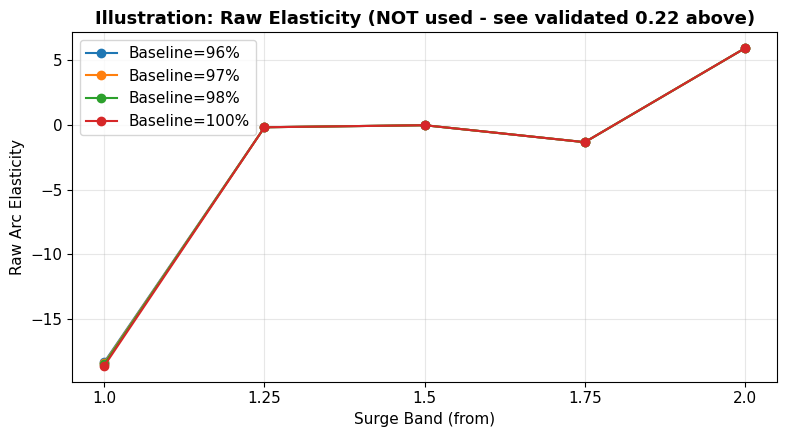

In [6]:
# WS2: Chart
fig, ax = plt.subplots(figsize=(8,4.5))
for bl in [0.96,0.97,0.98,1.0]:
    es = raw_arc_e(df, baseline_adj=bl)
    ax.plot(es['surge_from'].str.replace('x',''), es['raw_e'], 'o-', label=f'Baseline={bl:.0%}')
ax.set_xlabel('Surge Band (from)'); ax.set_ylabel('Raw Arc Elasticity')
ax.set_title('Illustration: Raw Elasticity (NOT used - see validated 0.22 above)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR,'ws2_elasticity_raw.png'),dpi=150,bbox_inches='tight'); plt.show()

---
## WORKSTREAM 3: Unit Economics & Customer LTV

In [7]:
# WS3: Churn model + DCF LTV
def annual_churn(sat):
    if sat<=1.5: return 0.55
    elif sat<=2.0: return 0.45
    elif sat<=2.5: return 0.38
    elif sat<=3.0: return 0.28
    elif sat<=3.5: return 0.20
    elif sat<=4.0: return 0.14
    elif sat<=4.5: return 0.10
    else: return 0.08

def monthly_churn(a): return 1-(1-a)**(1/12)
MONTHLY_DISC = (1.10)**(1/12)-1

def dcf_ltv(arpu, cm_pct, monthly_ch, months=18):
    ret, ltv = 1, 0
    for t in range(1,months+1):
        ret *= (1-monthly_ch)
        ltv += arpu*cm_pct*ret/(1+MONTHLY_DISC)**t
    return ltv

cust = df.groupby('customer_id').agg(
    avg_sat=('satisfaction_score','mean'), total_cm=('contribution_margin_inr','sum'),
    total_rev=('platform_revenue_inr','sum'), cac=('cac_inr','first'),
    segment=('customer_segment','first')
).reset_index()
cust['annual_churn'] = cust['avg_sat'].apply(annual_churn)
cust['monthly_churn'] = cust['annual_churn'].apply(monthly_churn)
cust['monthly_arpu'] = cust['total_rev']/12
cust['cm_pct'] = (cust['total_cm']/cust['total_rev'].replace(0,np.nan)).fillna(0).clip(-5,1)
cust['LTV'] = cust.apply(lambda r: dcf_ltv(r['monthly_arpu'],r['cm_pct'],r['monthly_churn']),axis=1)
cust['LTV_CAC'] = cust['LTV']/cust['cac']

seg_ltv = cust.groupby('segment').agg(
    avg_LTV=('LTV','mean'), avg_CAC=('cac','mean'),
    avg_churn=('annual_churn','mean'), avg_sat=('avg_sat','mean'),
    n_cust=('customer_id','count')
).round(2)
seg_ltv['LTV_CAC'] = (seg_ltv['avg_LTV']/seg_ltv['avg_CAC']).round(2)
print('LTV/CAC by Segment:')
print(seg_ltv.to_string())

LTV/CAC by Segment:
            avg_LTV  avg_CAC  avg_churn  avg_sat  n_cust  LTV_CAC
segment                                                          
frequent     487.37   331.03       0.14     3.78     768     1.47
occasional   276.92   395.38       0.14     3.79    1376     0.70
rare         101.87   466.73       0.15     3.78     856     0.22


In [8]:
# WS3: Churn sensitivity + NRR + Breakeven churn
print('\nChurn Sensitivity (LTV/CAC under rising churn):')
sens_rows = []
for seg in ['frequent','occasional','rare']:
    s = seg_ltv.loc[seg]
    arpu = cust[cust['segment']==seg]['monthly_arpu'].mean()
    cp = cust[cust['segment']==seg]['cm_pct'].mean()
    for label, mult in [('Base',1.0),('+25%',1.25),('+50%',1.50),('+100%',2.0)]:
        adj = s['avg_churn']*mult
        ltv = dcf_ltv(arpu,cp,monthly_churn(adj))
        sens_rows.append({'segment':seg,'scenario':label,'annual_churn':round(adj,3),
                         'LTV':round(ltv,1),'CAC':round(s['avg_CAC'],1),'LTV_CAC':round(ltv/s['avg_CAC'],2)})
print(pd.DataFrame(sens_rows).to_string(index=False))

# Breakeven churn: churn rate where LTV = CAC
print('\nBreakeven Churn Thresholds (where LTV = CAC):')
for seg in ['frequent','occasional','rare']:
    s = seg_ltv.loc[seg]
    arpu = cust[cust['segment']==seg]['monthly_arpu'].mean()
    cp = cust[cust['segment']==seg]['cm_pct'].mean()
    lo, hi = 0.001, 0.5
    for _ in range(50):
        mid = (lo+hi)/2
        if dcf_ltv(arpu,cp,mid) > s['avg_CAC']: lo = mid
        else: hi = mid
    be_annual = 1-(1-(lo+hi)/2)**12
    print(f'  {seg:11s}: LTV Rs.{s["avg_LTV"]:.0f}, CAC Rs.{s["avg_CAC"]:.0f}, breakeven churn = {be_annual:.1%} (current: {s["avg_churn"]:.1%})')

# NRR
churned = df.groupby('customer_id')['days_since_last_ride'].max() > 30
retained_rev = cust[~churned.values]['total_rev'].sum()
nrr = retained_rev/cust['total_rev'].sum()*100
cust_ret = 1 - churned.mean()
print(f'\nRevenue-weighted NRR: {nrr:.1f}% (customer retention: {cust_ret:.1%})')
print('Churned customers are predominantly low-value rare segment -> revenue NRR >> customer retention')
print('\nNOTE: Churn model uses industry benchmarks (sat->churn). NOT validated in this dataset (corr ~ -0.03).')
print('Recommendation rests on STRUCTURAL thesis (CM diversification + regulatory positioning), not churn improvement.')


Churn Sensitivity (LTV/CAC under rising churn):
   segment scenario  annual_churn   LTV   CAC  LTV_CAC
  frequent     Base         0.140 467.9 331.0     1.41
  frequent     +25%         0.175 453.7 331.0     1.37
  frequent     +50%         0.210 439.5 331.0     1.33
  frequent    +100%         0.280 411.0 331.0     1.24
occasional     Base         0.140 258.3 395.4     0.65
occasional     +25%         0.175 250.5 395.4     0.63
occasional     +50%         0.210 242.7 395.4     0.61
occasional    +100%         0.280 226.9 395.4     0.57
      rare     Base         0.150  78.8 466.7     0.17
      rare     +25%         0.188  76.2 466.7     0.16
      rare     +50%         0.225  73.7 466.7     0.16
      rare    +100%         0.300  68.5 466.7     0.15

Breakeven Churn Thresholds (where LTV = CAC):
  frequent   : LTV Rs.487, CAC Rs.331, breakeven churn = 47.5% (current: 14.0%)
  occasional : LTV Rs.277, CAC Rs.395, breakeven churn = 1.2% (current: 14.0%)
  rare       : LTV Rs.102, CAC

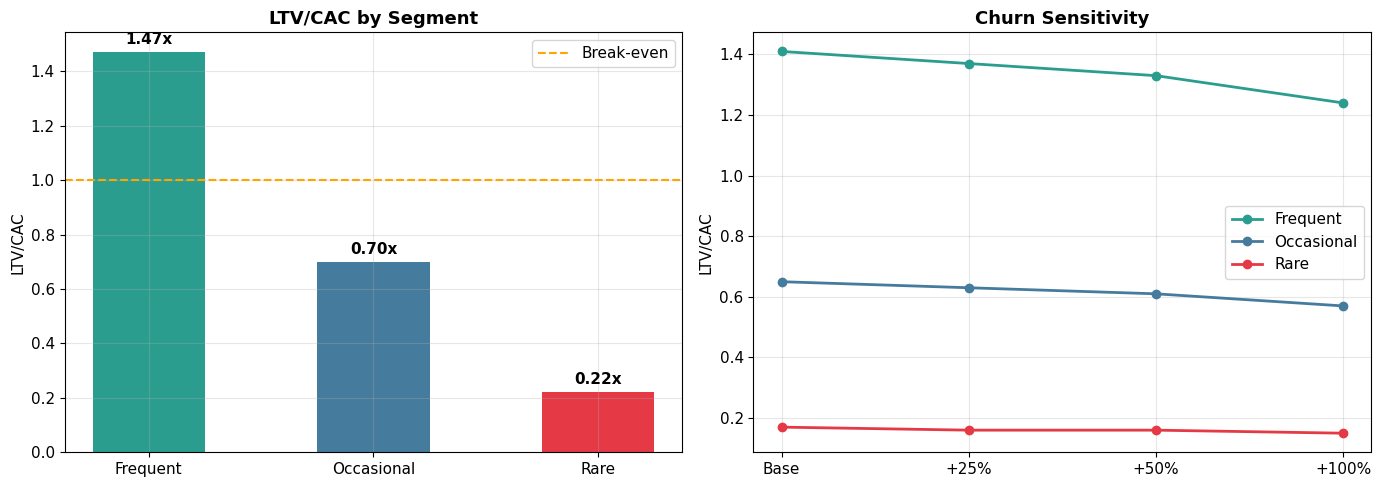

In [9]:
# WS3 charts
sdf = pd.DataFrame(sens_rows)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
segments = ['frequent','occasional','rare']
x = range(3)
ax = axes[0]
bars = ax.bar(x, seg_ltv.loc[segments,'LTV_CAC'], color=['#2A9D8F','#457B9D','#E63946'], width=0.5)
ax.set_xticks(x); ax.set_xticklabels(['Frequent','Occasional','Rare'])
ax.set_ylabel('LTV/CAC'); ax.set_title('LTV/CAC by Segment')
ax.axhline(y=1.0, color='orange', ls='--', label='Break-even'); ax.legend(); ax.grid(alpha=0.3)
for b,v in zip(bars,seg_ltv.loc[segments,'LTV_CAC']): ax.text(b.get_x()+b.get_width()/2,b.get_height()+0.03,f'{v:.2f}x',ha='center',fontweight='bold')

ax = axes[1]
for seg,c in zip(segments,['#2A9D8F','#457B9D','#E63946']):
    sub = sdf[sdf['segment']==seg]; ax.plot(sub['scenario'],sub['LTV_CAC'],'o-',label=seg.title(),color=c,lw=2)
ax.set_ylabel('LTV/CAC'); ax.set_title('Churn Sensitivity'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR,'ws3_ltv_cac.png'),dpi=150,bbox_inches='tight'); plt.show()

---
## WORKSTREAM 4: Scenario Simulation (Trip-Level)

In [10]:
# WS4: Trip-level simulation engine
comp_pts = [ADJ_BASE] + [comp_by_s[b] for b in SURGE_ORDER[1:]]
sat_pts = [sat_by_s[b] for b in SURGE_ORDER]
cancel_pts = [cancel_by_s[b] for b in SURGE_ORDER]

def adj_comp(s):
    if s <= 1.0: return ADJ_BASE
    return max(0,min(1,float(np.interp(s,SURGE_VALS,comp_pts))))
def adj_sat(s): return float(np.interp(s,SURGE_VALS,sat_pts))
def adj_cancel(s): return float(np.interp(s,SURGE_VALS,cancel_pts))

# Note: cost_per_trip treated as fully fixed when surge is capped.
# In reality, driver payout scales with fare. This assumption is CONSERVATIVE
# (overstates CM loss) because driver payout would also decrease.

scenarios = {
    'S0': {'desc':'Status Quo','type':'none'},
    'S1': {'desc':'Option 1: Calibrated Surge (2.0x)','type':'uniform','cap':2.0},
    'S2': {'desc':'Option 2: Zone Governance (Moderate 1.75/2.0/2.5x)','type':'zone',
           'residential':1.75,'commercial':2.0,'transit_hub':2.5},
    'S3a': {'desc':'Option 3: Loyalty Hard (1.5x Gold/Silver)','type':'loyalty','cap':1.5},
    'S3b': {'desc':'Option 3: Loyalty Soft (1.75x Gold/Silver)','type':'loyalty','cap':1.75},
    'S4': {'desc':'Combined: Zone + Loyalty (1.75x)','type':'combined',
           'residential':1.75,'commercial':2.0,'transit_hub':2.5,'loyalty_cap':1.75},
}

def run_scenario(sname,sparms):
    if sparms['type']=='none':
        return {'scenario':sname,'desc':sparms['desc'],'cm_pct':0.0,'rev_pct':0.0,
                'cancel_pp':0.0,'sat_delta':0.0,'trips_capped':0.0,
                'n_improved':0,'pct_improved':0.0,'churn_pp':0.0,
                'cm_annual':0,'ltv_gain':0,'net':0}
    t = df[['trip_id','customer_id','zone_type','surge_multiplier','fare_inr',
            'platform_revenue_inr','contribution_margin_inr','cost_per_trip',
            'ride_completed_int','cancel_int','satisfaction_score','loyalty_imputed']].copy()
    t['capped'] = False; t['eff_cap'] = np.nan
    if sparms['type']=='uniform':
        m = t['surge_multiplier']>sparms['cap']; t.loc[m,['capped','eff_cap']] = True,sparms['cap']
    elif sparms['type']=='zone':
        for z in ['residential','commercial','transit_hub']:
            m = (t['zone_type']==z)&(t['surge_multiplier']>sparms[z]); t.loc[m,['capped','eff_cap']] = True,sparms[z]
    elif sparms['type']=='loyalty':
        m = t['loyalty_imputed'].isin(['Gold','Silver'])&(t['surge_multiplier']>sparms['cap']); t.loc[m,['capped','eff_cap']] = True,sparms['cap']
    elif sparms['type']=='combined':
        for z in ['residential','commercial','transit_hub']:
            loyal = t['loyalty_imputed'].isin(['Gold','Silver'])
            eff = min(sparms['loyalty_cap'],sparms[z])
            t.loc[(t['zone_type']==z)&loyal&(t['surge_multiplier']>eff),['capped','eff_cap']] = True,eff
            t.loc[(t['zone_type']==z)&~loyal&(t['surge_multiplier']>sparms[z]),['capped','eff_cap']] = True,sparms[z]

    capped = t['capped']; n_capped = capped.sum()
    cm_delta = rev_delta = cancel_d = 0.0
    if n_capped>0:
        ct = t[capped].copy()
        ratio = ct['eff_cap']/ct['surge_multiplier']
        ct['new_rev'] = ct['platform_revenue_inr']*ratio
        ct['new_cm'] = ct['new_rev'] - ct['cost_per_trip']  # conservative: fixed cost
        ct['new_comp'] = ct['eff_cap'].apply(adj_comp)
        ct['new_cancel'] = ct['eff_cap'].apply(adj_cancel)
        ct['demand_inc'] = avg_e*abs(1-ratio)
        cm_delta = ((ct['new_cm']*ct['new_comp']*(1+ct['demand_inc']))
                   -(ct['contribution_margin_inr']*ct['ride_completed_int'])).sum()
        rev_delta = ((ct['new_rev']*ct['new_comp']*(1+ct['demand_inc']))
                    -(ct['platform_revenue_inr']*ct['ride_completed_int'])).sum()
        cancel_d = (ct['new_cancel']-ct['cancel_int']).sum()
    # Satisfaction -> churn (customer-level, across ALL trips)
    t['new_sat'] = t['satisfaction_score'].copy()
    if n_capped>0:
        ct['new_sat'] = ct['eff_cap'].apply(adj_sat); t.loc[capped,'new_sat'] = ct['new_sat'].values
    cust_ns = t.groupby('customer_id')['new_sat'].mean().reset_index()
    cust_ns.columns = ['customer_id','new_sat']
    cs = cust[['customer_id','monthly_arpu','cm_pct','avg_sat','LTV','annual_churn']].merge(cust_ns,on='customer_id')
    cs['new_churn'] = cs['new_sat'].apply(annual_churn)
    cs['churn_d'] = cs['annual_churn']-cs['new_churn']
    cs['new_LTV'] = cs.apply(lambda r: dcf_ltv(r['monthly_arpu'],r['cm_pct'],monthly_churn(r['new_churn'])),axis=1)
    ltv_gain = (cs['new_LTV']-cs['LTV']).sum()
    return {
        'scenario':sname,'desc':sparms['desc'],
        'cm_pct':round(cm_delta/TOTAL_CM*100,2),'rev_pct':round(rev_delta/TOTAL_REV*100,2),
        'cancel_pp':round(cancel_d/TOTAL_TRIPS*100,2),
        'sat_delta':round((t['new_sat'].mean()-t['satisfaction_score'].mean()),3),
        'trips_capped':round(n_capped/TOTAL_TRIPS*100,1),
        'n_improved':(cs['new_churn']<cs['annual_churn']).sum(),
        'pct_improved':round((cs['new_churn']<cs['annual_churn']).mean()*100,1),
        'churn_pp':round(cs['churn_d'].mean()*100,2),
        'cm_annual':round(cm_delta),  # data is annual (50K trips = 1 year)
        'ltv_gain':round(ltv_gain),'net':round(cm_delta+ltv_gain),
    }

print('Running trip-level simulation...')
sim = [run_scenario(k,v) for k,v in scenarios.items()]
sim_df = pd.DataFrame(sim)
for _,r in sim_df.iterrows():
    print(f'  {r["scenario"]}: CM={r["cm_pct"]:+.2f}% Rev={r["rev_pct"]:+.2f}% Churn={r["churn_pp"]:+.2f}pp Capped={r["trips_capped"]:.1f}%')

active = sim_df[sim_df['scenario']!='S0']  # scenario subset for charts and scoring

Running trip-level simulation...
  S0: CM=+0.00% Rev=+0.00% Churn=+0.00pp Capped=0.0%
  S1: CM=-5.36% Rev=-1.84% Churn=+0.53pp Capped=10.4%
  S2: CM=-5.64% Rev=-1.50% Churn=+0.64pp Capped=10.7%
  S3a: CM=-5.11% Rev=-1.42% Churn=+0.46pp Capped=6.2%
  S3b: CM=-2.42% Rev=-0.48% Churn=+0.25pp Capped=4.7%
  S4: CM=-6.49% Rev=-1.59% Churn=+0.74pp Capped=12.1%


In [11]:
# WS4: Results table
COLS = ['desc','cm_pct','rev_pct','cancel_pp','trips_capped','pct_improved','churn_pp','cm_annual','ltv_gain','net']
print(sim_df[COLS].to_string(index=False))

                                              desc  cm_pct  rev_pct  cancel_pp  trips_capped  pct_improved  churn_pp  cm_annual  ltv_gain    net
                                        Status Quo    0.00     0.00       0.00           0.0           0.0      0.00          0         0      0
                 Option 1: Calibrated Surge (2.0x)   -5.36    -1.84       0.05          10.4          10.3      0.53     -36477      3803 -32674
Option 2: Zone Governance (Moderate 1.75/2.0/2.5x)   -5.64    -1.50      -0.57          10.7          12.2      0.64     -38361      4647 -33714
         Option 3: Loyalty Hard (1.5x Gold/Silver)   -5.11    -1.42      -0.41           6.2          10.3      0.46     -34781      3523 -31258
        Option 3: Loyalty Soft (1.75x Gold/Silver)   -2.42    -0.48      -0.46           4.7           5.5      0.25     -16435      1938 -14498
                  Combined: Zone + Loyalty (1.75x)   -6.49    -1.59      -0.84          12.1          14.4      0.74     -44146   

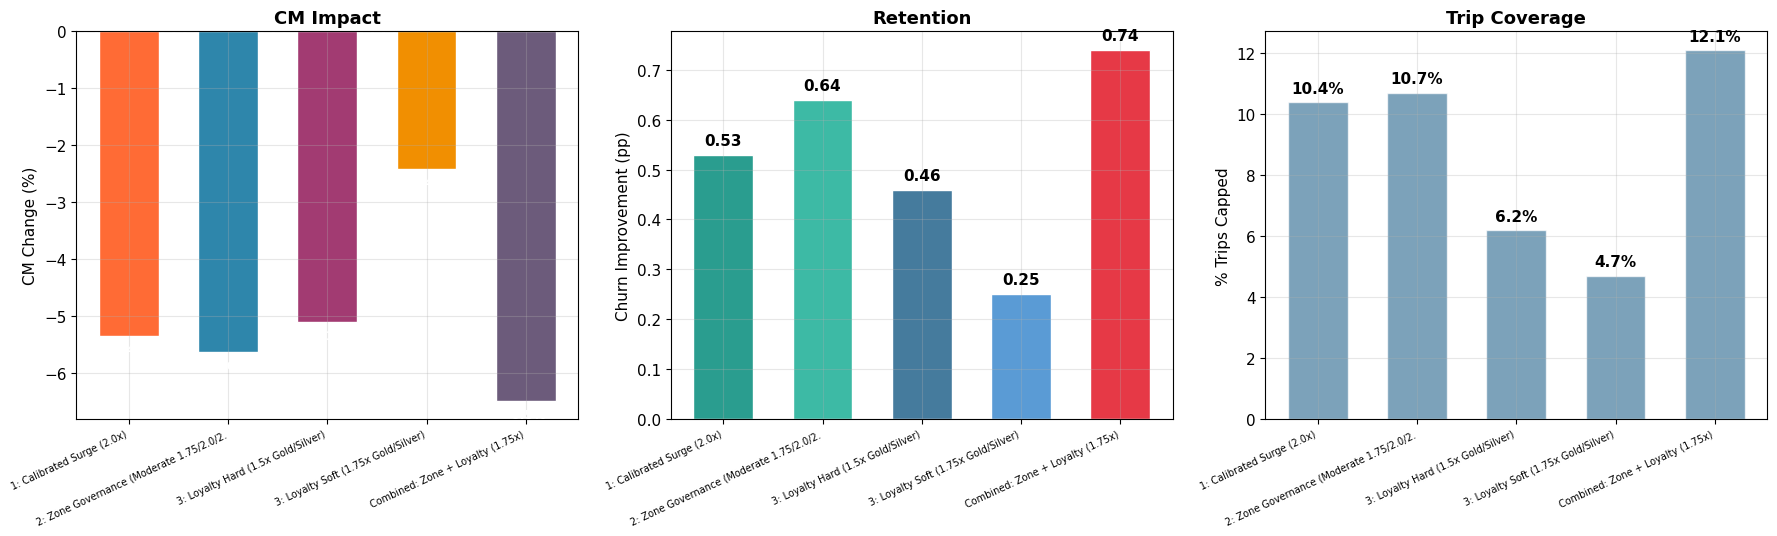

In [12]:
# WS4: Charts
fig, axes = plt.subplots(1, 3, figsize=(18,5.5))
labels = [r['desc'].replace('Option ','')[:40] for _,r in active.iterrows()]
x = range(len(active))
ax = axes[0]
bars = ax.bar(x, active['cm_pct'], color=['#FF6B35','#2E86AB','#A23B72','#F18F01','#6C5B7B'], width=0.6, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=7)
ax.set_ylabel('CM Change (%)'); ax.set_title('CM Impact'); ax.axhline(0,color='gray',ls='--',alpha=0.5); ax.grid(alpha=0.3)
for b,v in zip(bars,active['cm_pct']): ax.text(b.get_x()+b.get_width()/2,b.get_height()-0.3,f'{v:.1f}%',ha='center',fontweight='bold',fontsize=9,color='white')

ax = axes[1]
ax.bar(x, active['churn_pp'], color=['#2A9D8F','#3DBAA5','#457B9D','#5A9BD5','#E63946'], width=0.6, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=7)
ax.set_ylabel('Churn Improvement (pp)'); ax.set_title('Retention'); ax.grid(alpha=0.3)
for i,v in enumerate(active['churn_pp']): ax.text(i,v+0.02,f'{v:.2f}',ha='center',fontweight='bold')

ax = axes[2]
ax.bar(range(len(active)), active['trips_capped'], color='#457B9D', width=0.6, edgecolor='white', alpha=0.7)
ax.set_xticks(range(len(active))); ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=7)
ax.set_ylabel('% Trips Capped'); ax.set_title('Trip Coverage'); ax.grid(alpha=0.3)
for i,v in enumerate(active['trips_capped']): ax.text(i,v+0.3,f'{v:.1f}%',ha='center',fontweight='bold')
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR,'ws4_simulation.png'),dpi=150,bbox_inches='tight'); plt.show()

---
## STRATEGIC OPTIONS EVALUATION

Note: Status Quo (S0) is excluded from scoring because the problem statement evaluates 3 GIVEN options. If desired, S0 can be scored inline as a baseline.

In [13]:
# Multi-criteria scoring
scoring = []
for _,r in active.iterrows():
    desc = r['desc']
    cm_s = max(1,min(5,5+r['cm_pct']/3))
    cancel_s = max(1,min(5,3+abs(r['cancel_pp'])*2))
    churn_s = max(1,min(5,3+r['churn_pp']*5))
    reg_s = 5 if 'Zone' in desc else (3 if 'Loyalty' in desc else 2)
    impl_s = 4 if ('Moderate' in desc or 'Soft' in desc) else 2
    strat_s = 5 if 'Zone' in desc else (3 if 'Loyalty' in desc and 'Soft' in desc else 2)
    w = {'CM':0.15,'Cancel':0.10,'Churn':0.15,'Reg':0.20,'Impl':0.15,'Strat':0.25}
    s = {'CM':cm_s,'Cancel':cancel_s,'Churn':churn_s,'Reg':reg_s,'Impl':impl_s,'Strat':strat_s}
    scoring.append({'Option':desc,**s,'Weighted':round(sum(s[k]*w[k] for k in w),2)})
score_df = pd.DataFrame(scoring).sort_values('Weighted',ascending=False)
print(score_df.to_string(index=False))
BEST = score_df.iloc[0]['Option']

                                            Option       CM  Cancel  Churn  Reg  Impl  Strat  Weighted
Option 2: Zone Governance (Moderate 1.75/2.0/2.5x) 3.120000    4.14   5.00    5     4      5      4.48
                  Combined: Zone + Loyalty (1.75x) 2.836667    4.68   5.00    5     2      5      4.19
        Option 3: Loyalty Soft (1.75x Gold/Silver) 4.193333    3.92   4.25    3     4      3      3.61
         Option 3: Loyalty Hard (1.5x Gold/Silver) 3.296667    3.82   5.00    3     2      2      3.03
                 Option 1: Calibrated Surge (2.0x) 3.213333    3.10   5.00    2     2      2      2.74


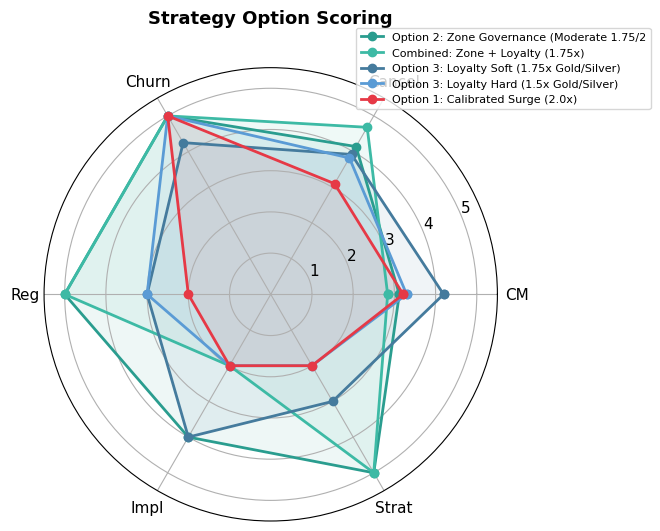

In [14]:
# Radar chart
cats = ['CM','Cancel','Churn','Reg','Impl','Strat']
fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))
angles = np.linspace(0,2*np.pi,len(cats),endpoint=False).tolist()+[0]
for idx,(_,row) in enumerate(score_df.iterrows()):
    vals = [row[c] for c in cats]+[row[cats[0]]]
    ax.plot(angles,vals,'o-',lw=2,label=row['Option'][:42],color=['#2A9D8F','#3DBAA5','#457B9D','#5A9BD5','#E63946'][idx])
    ax.fill(angles,vals,alpha=0.08,color=['#2A9D8F','#3DBAA5','#457B9D','#5A9BD5','#E63946'][idx])
ax.set_xticks(angles[:-1]); ax.set_xticklabels(cats); ax.set_ylim(0,5.5)
ax.set_title('Strategy Option Scoring', y=1.08)
ax.legend(loc='upper right',bbox_to_anchor=(1.35,1.1),fontsize=8)
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR,'options_radar.png'),dpi=150,bbox_inches='tight'); plt.show()

---
## COMPETITIVE ANALYSIS: Porter's Five Forces

In [15]:
print('Porters Five Forces:')
print(pd.DataFrame([
    ('Buyer Power','HIGH','Multi-apping is norm (75%+ have 2+ apps). Zero switching cost.'),
    ('Supplier Power','MODERATE','Drivers multi-home but platform-dependent. Earnings sensitivity to surge caps is #1 risk.'),
    ('Rivalry','HIGH','Ola, Uber, Rapido. Intense price competition. Winner-take-most dynamics.'),
    ('Substitutes','VERY HIGH','Metro, autos, buses. Short-distance (<3km) especially substitutable.'),
    ('New Entrants','MODERATE','Network effects barrier. Zero-surge positioning attracts switchers but burns cash.'),
], columns=['Force','Intensity','Assessment']).to_string(index=False))

print('\nPricing Defensibility:')
print(pd.DataFrame([
    ('Uniform Cap (2.0x)','LOW','Immediately observable. Competitor can match within hours.'),
    ('Zone Governance','HIGH','Caps invisible until ride request. Per-zone caps impossible to reverse-engineer.'),
    ('Loyalty Protection','MEDIUM','Tier-based. 37% Unknown tier lacks protection. Hard to communicate.'),
], columns=['Strategy','Defensibility','Assessment']).to_string(index=False))

Porters Five Forces:
         Force Intensity                                                                                Assessment
   Buyer Power      HIGH                            Multi-apping is norm (75%+ have 2+ apps). Zero switching cost.
Supplier Power  MODERATE Drivers multi-home but platform-dependent. Earnings sensitivity to surge caps is #1 risk.
       Rivalry      HIGH                  Ola, Uber, Rapido. Intense price competition. Winner-take-most dynamics.
   Substitutes VERY HIGH                      Metro, autos, buses. Short-distance (<3km) especially substitutable.
  New Entrants  MODERATE        Network effects barrier. Zero-surge positioning attracts switchers but burns cash.

Pricing Defensibility:
          Strategy Defensibility                                                                       Assessment
Uniform Cap (2.0x)           LOW                       Immediately observable. Competitor can match within hours.
   Zone Governance          HIGH Caps

---
## IMPLEMENTATION ROADMAP & RISK REGISTRY

In [16]:
print('Implementation Plan:')
print(pd.DataFrame([
    ('Phase 1 (M1-2)','Foundation','Zone-classification engine. Shadow mode at 1.75x residential. A/B test 5%.','Accuracy >95%'),
    ('Phase 2 (M3-4)','Zone Caps Live','Res 1.75x, Com 2.0x, Transit 2.5x. Driver earnings guarantee.','Satisfaction +0.05'),
    ('Phase 3 (M5-6)','Loyalty Protection','Gold/Silver 1.75x enhancement. Path-to-Silver for Unknown/Bronze.','Gold retention +2pp'),
    ('Phase 4 (M7-12)','Optimization','Fine-tune from 6-month A/B data. Dynamic seasonal adjustments.','Net CM +2%'),
    ('Phase 5 (M13-18)','Scale & Series D','Full zone+loyalty operational. Series D readiness.','NRR >=95% from ~94%'),
], columns=['Phase','Theme','Actions','Success Metric']).to_string(index=False))

print('\nRisk Registry:')
print(pd.DataFrame([
    ('CRITICAL','Driver earnings','Residential zone drivers lose surge revenue','Earnings guarantee 6mo; 1.25x surge floor'),
    ('HIGH','Competitor matching','Competitors match caps','Zone caps invisible pre-request; reliability differentiation'),
    ('HIGH','Unknown tier gap','37% of customers unprotected','Path-to-Silver gamification'),
    ('MEDIUM','Regulatory','Government mandates uniform caps','Proactive self-regulation narrative'),
], columns=['Severity','Risk','Description','Mitigation']).to_string(index=False))

Implementation Plan:
           Phase              Theme                                                                    Actions      Success Metric
  Phase 1 (M1-2)         Foundation Zone-classification engine. Shadow mode at 1.75x residential. A/B test 5%.       Accuracy >95%
  Phase 2 (M3-4)     Zone Caps Live              Res 1.75x, Com 2.0x, Transit 2.5x. Driver earnings guarantee.  Satisfaction +0.05
  Phase 3 (M5-6) Loyalty Protection          Gold/Silver 1.75x enhancement. Path-to-Silver for Unknown/Bronze. Gold retention +2pp
 Phase 4 (M7-12)       Optimization             Fine-tune from 6-month A/B data. Dynamic seasonal adjustments.          Net CM +2%
Phase 5 (M13-18)   Scale & Series D                         Full zone+loyalty operational. Series D readiness. NRR >=95% from ~94%

Risk Registry:
Severity                Risk                                 Description                                                   Mitigation
CRITICAL     Driver earnings Residential zo

---
## INVESTOR NARRATIVE (18-Month)

In [17]:
print('Investor Narrative:')
print(pd.DataFrame([
    ('LTV/CAC (Frequent)',f'{seg_ltv.loc["frequent","LTV_CAC"]:.2f}x','1.47-1.84x','Churn reduction from zone governance','MEDIUM'),
    ('CM Sustainability',f'{cm_surge_pct:.1f}% surge-dep.','<55% surge-dep.','Zone caps shift from surge-dependent to volume-driven','MEDIUM-HIGH'),
    ('NRR (Revenue-Weighted)',f'{nrr:.1f}%','>=95%','Zone governance improves residential satisfaction','MEDIUM-HIGH'),
], columns=['Metric','Current','Target','Driver','Confidence']).to_string(index=False))

Investor Narrative:
                Metric          Current          Target                                                Driver  Confidence
    LTV/CAC (Frequent)            1.47x      1.47-1.84x                  Churn reduction from zone governance      MEDIUM
     CM Sustainability 62.8% surge-dep. <55% surge-dep. Zone caps shift from surge-dependent to volume-driven MEDIUM-HIGH
NRR (Revenue-Weighted)            94.2%           >=95%     Zone governance improves residential satisfaction MEDIUM-HIGH


---
## CONCLUSION

In [18]:
print('='*70)
print('FINAL RECOMMENDATION')
print('='*70)
print(f'Recommended: {BEST}')
print(f'Weighted Score: {score_df.iloc[0]["Weighted"]:.2f} / 5')
print()
print('CANONICAL KEY NUMBERS (computed live from data)')
print(f'  Cancellation:     {cancel_by_s["1.0x"]:.0%} at 1.0x -> {cancel_by_s["2.5x"]:.0%} at 2.5x')
print(f'  Satisfaction:     {sat_by_s["1.0x"]:.2f} at 1.0x -> {sat_by_s["2.5x"]:.2f} at 2.5x (transition ~1.5x)')
print(f'  Negative margin:  {pct_neg:.0%} of trips (concentrated <3km + 1.0x)')
print(f'  CM from surge:    {cm_surge_pct:.1f}% (from {surge_trip_pct:.1f}% of volume)')
print(f'  Elasticity:       {avg_e:.2f} (97% baseline, controlled regression) -- INELASTIC')
print(f'  LTV/CAC:          Frequent {seg_ltv.loc["frequent","LTV_CAC"]:.2f}x | Occasional {seg_ltv.loc["occasional","LTV_CAC"]:.2f}x | Rare {seg_ltv.loc["rare","LTV_CAC"]:.2f}x')
print(f'  NRR (revenue-wtd): {nrr:.1f}% (churned customers are low-value rare segment)')
print(f'  Zone Gov CM:      {sim_df[sim_df["scenario"]=="S2"]["cm_pct"].values[0]:.2f}% annually')
print(f'  Zone Gov Churn:   +{sim_df[sim_df["scenario"]=="S2"]["churn_pp"].values[0]:.2f}pp improvement (confidence: MEDIUM-LOW)')
print()
print('STRUCTURAL THESIS (not dependent on churn validation):')
print(f'  (1) CM diversification -- reduce {cm_surge_pct:.1f}% surge dependency')
print('  (2) Regulatory positioning -- self-regulation beats government mandate')
print('  (3) Competitive defensibility -- zone caps invisible pre-request')

FINAL RECOMMENDATION
Recommended: Option 2: Zone Governance (Moderate 1.75/2.0/2.5x)
Weighted Score: 4.48 / 5

CANONICAL KEY NUMBERS (computed live from data)
  Cancellation:     0% at 1.0x -> 18% at 2.5x
  Satisfaction:     4.14 at 1.0x -> 2.36 at 2.5x (transition ~1.5x)
  Negative margin:  40% of trips (concentrated <3km + 1.0x)
  CM from surge:    62.8% (from 31.2% of volume)
  Elasticity:       0.22 (97% baseline, controlled regression) -- INELASTIC
  LTV/CAC:          Frequent 1.47x | Occasional 0.70x | Rare 0.22x
  NRR (revenue-wtd): 94.2% (churned customers are low-value rare segment)
  Zone Gov CM:      -5.64% annually
  Zone Gov Churn:   +0.64pp improvement (confidence: MEDIUM-LOW)

STRUCTURAL THESIS (not dependent on churn validation):
  (1) CM diversification -- reduce 62.8% surge dependency
  (2) Regulatory positioning -- self-regulation beats government mandate
  (3) Competitive defensibility -- zone caps invisible pre-request
